# Module 1: Linear Regression - California Housing

In this notebook, we predict house prices in California using **Linear Regression**. Linear regression models the relationship between a dependent variable $y$ and one or more independent variables $X$.

### 1.1 The Mathematical Model
The hypothesis function $h_\theta(x)$ is defined as:
$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$$

### 1.2 The Cost Function: Mean Squared Error (MSE)
We measure performance by calculating the average squared difference between predictions and actual values:
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

### 1.3 Optimization: Gradient Descent
We update parameters $\theta_j$ iteratively to minimize $J(\theta)$:
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

### Linear Regression Workflow
```mermaid
graph TD
    A[Data Selection] --> B[Feature Engineering]
    B --> C[Model Training]
    C --> D[Cost Function Evaluation]
    D --> E{Converged?}
    E -- No --> F[Update Parameters via Gradient Descent]
    F --> C
    E -- Yes --> G[Final Model & Evaluation]
```

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set(style="whitegrid")

## 2. Load and Explore Data

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


### Data Structure Overview
The California Housing dataset contains the following features:
```mermaid
classDiagram
    class CaliforniaHousing {
        +MedInc (Income)
        +HouseAge
        +AveRooms
        +AveBedrms
        +Population
        +AveOccup
        +Latitude
        +Longitude
        +MedHouseVal (Target)
    }
```


## 3. Spatial Visualization
Since we have latitude and longitude, let's see the distribution of prices geographically.

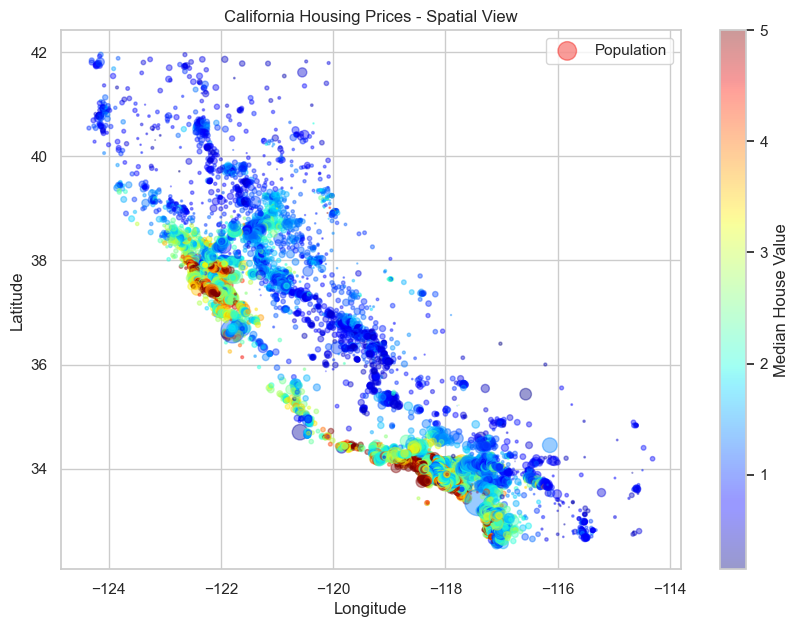

In [4]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], 
            alpha=0.4, s=df['Population']/100, label='Population', 
            cmap=plt.get_cmap('jet'))
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices - Spatial View')
plt.legend()
plt.show()

## 4. Prep Data for Modeling

In [5]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (16512, 8)
Test set: (4128, 8)


## 5. Train Linear Regression Model

### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


### Training: Minimizing the Residuals
Linear regression uses **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.
```mermaid
graph LR
    X[Features] --> M((Model Weights))
    M --> P[Predictions]
    P --> E{MSE Calculation}
    E -->|Update Weights| M
```


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. Evaluation

In [7]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 0.5559
R2 Score: 0.5758
